Descargo de responsabilidad:

Esta investigacion es puramente informativa y no constituye asesoramiento financiero. No se recomienda tomar decisiones de inversión basadas únicamente en esta información. Se aconseja realizar un análisis propio y consultar a un profesional financiero antes de tomar decisiones de inversión. Las decisiones de inversión son responsabilidad exclusiva del lector.

En todo momento se incita a hacer un análisis propio, y saber que tus decisiones son completamente tuyas y afectan tus inversiones y tu patrimonio.

● No es una asesoría financiera.

● No supone en ningún caso, esto sea recomendación de inversión, de compra o de venta de ningún activo/bien o subyacente.

● El contenido de la investigacion es meramente informativo.

● En todo momento se incita a hacer un análisis propio, y saber que tus decisiones son completamente tuyas y afectan tus inversiones y tu patrimonio.

In [8]:
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math

# Agregar el directorio src al path
current_dir = Path.cwd()
src_path = current_dir.parent / 'src'
sys.path.append(str(src_path))

# Importaciones del modulo
from optimizacion_portafolios import (
    cargar_datos_historicos, 
    descargar_datos_historicos,
    calcular_rendimientos_diarios,
    calcular_matriz_covarianza,
    calcular_rendimientos_esperados_capm,
    calcular_betas,
    muestreo_aleatorio,
    algoritmo_genetico,
    temple_simulado,
    TICKERS, PERFILES
)

plt.style.use('ggplot')
print("Modulos importados correctamente.")

Modulos importados correctamente.


# Optimizacion de Carteras de Inversion con modelos Metahuristicos

## 1. Descripcion del Problema
El objetivo es construir un portafolio de inversion optimo seleccionando entre 20 activos del S&P 500 con mayor capitalizacion en sus respectivos sectores.
El problema se modela bajo la **Teoria Moderna de Carteras**, buscando maximizar el **Ratio de Sharpe** (rendimiento ajustado al riesgo).

El problema esta sujeto a restricciones estrictas segun el perfil del inversor (Conservador, Moderado, Agresivo):
1.  **Volatilidad Maxima:** Limite de riesgo permitido.
2.  **Concentracion Sectorial:** Limite de exposicion a sectores volatiles (Tecnologia).
3.  **Peso Maximo por Activo:** Para evitar falta de diversificacion.

## 2. Datos
Se utilizan datos historicos de los ultimos 10 años (precios de cierre ajustados) obtenidos via Yahoo Finance.

Datos cargados: 2513 dias de trading para 20 activos.
Tasa Libre de Riesgo (Risk Free): 4.11%


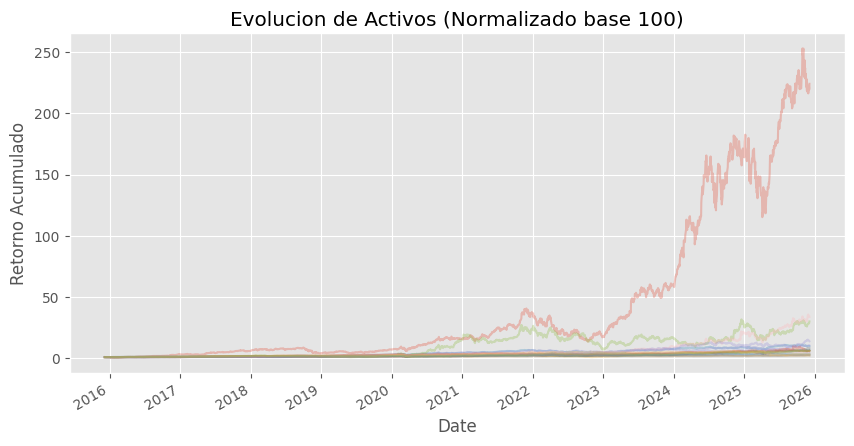

In [9]:
# Cargar datos
try:
    datos = cargar_datos_historicos('../data')
except FileNotFoundError:
    print("Datos no encontrados, descargando...")
    datos = descargar_datos_historicos(years=10, data_dir='../data')

precios = datos['precios'][TICKERS]
mercado = datos['mercado']
rf_series = datos['tasa_libre_riesgo']

# Tasa libre de riesgo actual
rf_val = float(rf_series.iloc[-1])
if rf_val > 1: rf_val /= 100

print(f"Datos cargados: {precios.shape[0]} dias de trading para {precios.shape[1]} activos.")
print(f"Tasa Libre de Riesgo (Risk Free): {rf_val:.2%}")

# Visualizacion de precios normalizados
(precios / precios.iloc[0]).plot(figsize=(10, 5), legend=False, alpha=0.3)
plt.title("Evolucion de Activos (Normalizado base 100)")
plt.ylabel("Retorno Acumulado")
plt.show()

## 3. Modelado
### Representacion de la Solucion
La solucion se representa como un vector de pesos $w = [w_1, w_2, ..., w_{20}]$ donde:
* $\sum w_i = 1$ (100% del capital invertido)
* $0 \le w_i \le 1$ (Solo posiciones largas, no ventas en corto)

### Funcion de Costo (Fitness)
Buscamos **Maximizar** el Ratio de Sharpe. Sin embargo, para manejar las restricciones, utilizamos una funcion de Fitness penalizada:
$$Fitness = Sharpe - (Penalizacion \times Violaciones)$$

In [10]:
# Calculos financieros base necesarios para la optimizacion
r_diarios = calcular_rendimientos_diarios(precios)
r_mercado = calcular_rendimientos_diarios(mercado)
matriz_cov = calcular_matriz_covarianza(r_diarios)

# Calcular Betas y Rendimientos Esperados con Capital Asset Pricing Model (CAPM)
betas = calcular_betas(r_diarios, r_mercado)
rm = r_mercado.mean() * 252 # Retorno anualizado del mercado
r_esp = calcular_rendimientos_esperados_capm(betas, rf_val, rm)

print("Rendimientos Esperados (Top 5):")
print(r_esp.sort_values(ascending=False).head())

Rendimientos Esperados (Top 5):
NVDA    0.183413
TSLA    0.169102
AVGO    0.154366
META    0.144720
AAPL    0.136728
dtype: float64


## 4. Busqueda Exhaustiva
Dado que el espacio de pesos es continuo, el numero de soluciones es infinito.
Para estimar la complejidad, discretizamos el problema: supongamos que solo podemos asignar pesos en pasos del 1%.
Esto equivale a repartir 100 puntos porcentuales entre 20 activos.

Formula de combinaciones con repeticion (Stars and Bars):
$$N = \binom{n + k - 1}{k - 1}$$
Donde $n=100$ (puntos) y $k=20$ (activos).

In [11]:
n_puntos = 100
k_activos = 20

# Calculo combinatorio
combinaciones = math.comb(n_puntos + k_activos - 1, k_activos - 1)

print(f"Numero de combinaciones posibles discretizado al 1%: {combinaciones:,.0f}")

# Estimacion de tiempo
tiempo_por_evaluacion = 0.0001 # segundos
tiempo_total_segundos = combinaciones * tiempo_por_evaluacion
tiempo_anos = tiempo_total_segundos / (3600 * 24 * 365)

print(f"\nSi evaluamos 10,000 soluciones por segundo, tardariamos:")
print(f"{tiempo_anos:,.0f} AÑOS en encontrar la solucion optima.")
print("CONCLUSION: La busqueda exhaustiva es inviable.")

Numero de combinaciones posibles discretizado al 1%: 4,910,371,215,196,105,474,048

Si evaluamos 10,000 soluciones por segundo, tardariamos:
15,570,684,980 AÑOS en encontrar la solucion optima.
CONCLUSION: La busqueda exhaustiva es inviable.


## 5. Muestreo Aleatorio con Monte Carlo
Generamos 10,000 carteras aleatorias para entender la distribucion del espacio de soluciones y establecer una linea base para comparar nuestros algoritmos.


CUESTIONARIO DE PERFILAMIENTO DE INVERSIONISTA
Responder ingresando el NUMERO de la opcion (1, 2 o 3).


1. Horizonte de inversion: ¿Cuanto tiempo planea mantener sus inversiones?
   [1] Mas de 5 anos
   [2] Menos de 1 ano
   [3] Entre 1 y 5 anos
   Entrada invalida. Ingrese un numero.
------------------------------

2. Reaccion ante perdidas: Si su portafolio pierde un 15% en un mes, ¿que haria?
   [1] Vender inmediatamente para evitar mas perdidas
   [2] Comprar mas porque ve una oportunidad
   [3] Mantener la inversion esperando recuperacion
------------------------------

3. Experiencia previa: ¿Cual es su nivel de experiencia en inversiones?
   [1] Intermedia (fondos, CETES, ETFs)
   [2] Ninguna o muy basica (cuentas de ahorro)
   [3] Avanzada (acciones, derivados, cripto)
------------------------------

4. Preferencia: ¿Que es mas importante para usted?
   [1] Balance entre seguridad y crecimiento
   [2] Seguridad y estabilidad del capital
   [3] Maximo crecimiento aunque impliq

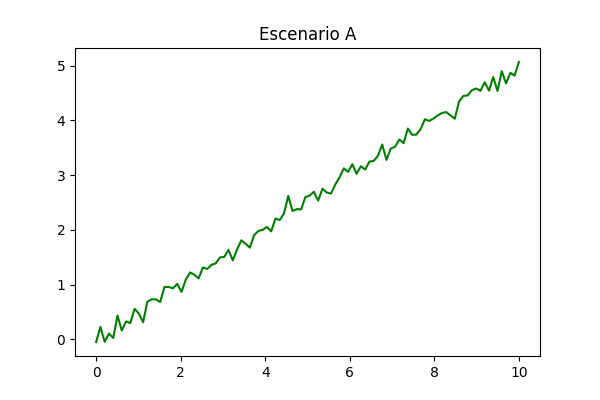

   [1] Escenario A


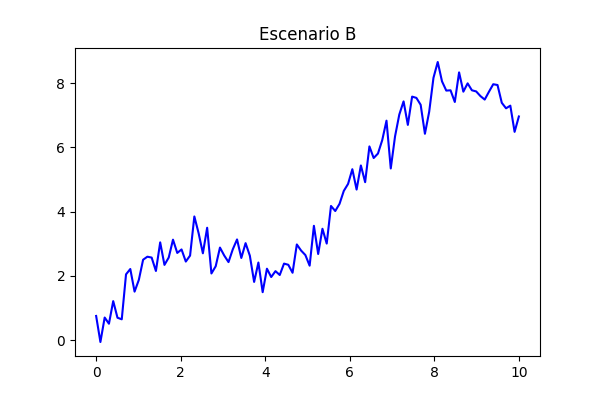

   [2] Escenario B


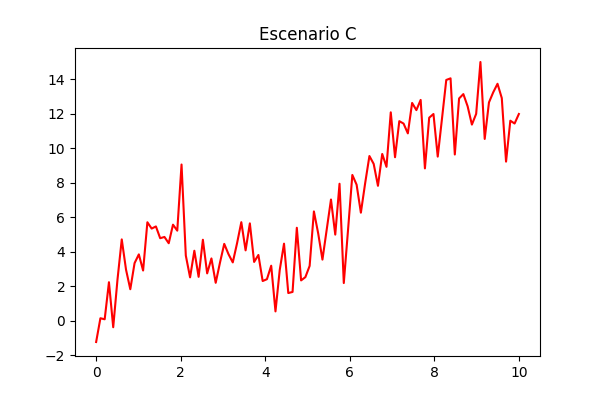

   [3] Escenario C

PUNTAJE TOTAL: 9/15
PERFIL DETERMINADO: MODERADO

El perfil seleccionado para la optimizacion es: Moderado
Generando 10000 carteras aleatorias (Perfil: Moderado)...


In [12]:
from optimizacion_portafolios import ejecutar_cuestionario_perfil

# Ejecutar cuestionario interactivo
PERFIL_ACTUAL = ejecutar_cuestionario_perfil()

print(f"El perfil seleccionado para la optimizacion es: {PERFIL_ACTUAL}")

best_random, df_random = muestreo_aleatorio(
    n_muestras=10000,
    tickers=TICKERS,
    rendimientos_esp=r_esp,
    matriz_cov=matriz_cov,
    rf=rf_val,
    rendimientos_diarios=r_diarios,
    perfil=PERFIL_ACTUAL
)

Mejor Sharpe Aleatorio: 0.4119


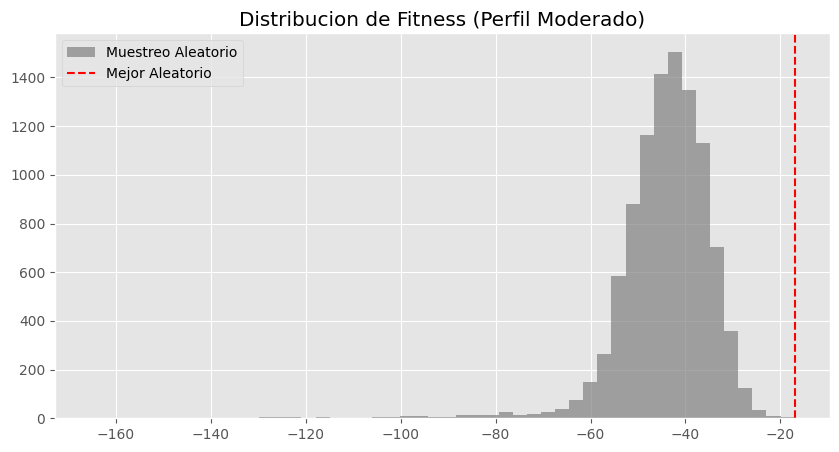

In [13]:
print(f"Mejor Sharpe Aleatorio: {best_random['sharpe']:.4f}")

# Histograma
plt.figure(figsize=(10, 5))
plt.hist(df_random['fitness'], bins=50, alpha=0.7, color='gray', label='Muestreo Aleatorio')
plt.axvline(best_random['fitness'], color='red', linestyle='--', label='Mejor Aleatorio')
plt.title(f"Distribucion de Fitness (Perfil {PERFIL_ACTUAL})")
plt.legend()
plt.show()

## 6. Metodo de Optimizacion: Algoritmo Genetico
Utilizamos un Algoritmo Genetico (GA) para evolucionar una poblacion de carteras hacia el optimo global.
* **Poblacion:** 200 individuos.
* **Generaciones:** 300.
* **Mutacion:** 15% de probabilidad.

GA iniciado (Perfil: Moderado). Generaciones: 300
  Gen 20/300 - Mejor Fit: 0.3993
  Gen 40/300 - Mejor Fit: 0.4013
  Gen 60/300 - Mejor Fit: 0.4019
  Gen 80/300 - Mejor Fit: 0.4022
  Gen 100/300 - Mejor Fit: 0.4023
  Gen 120/300 - Mejor Fit: 0.4024
  Gen 140/300 - Mejor Fit: 0.4024
  Gen 160/300 - Mejor Fit: 0.4024
  Gen 180/300 - Mejor Fit: 0.4024
  Gen 200/300 - Mejor Fit: 0.4024
  Gen 220/300 - Mejor Fit: 0.4024
  Gen 240/300 - Mejor Fit: 0.4024
  Gen 260/300 - Mejor Fit: 0.4024
  Gen 280/300 - Mejor Fit: 0.4024
  Gen 300/300 - Mejor Fit: 0.4024

Mejor Sharpe GA: 0.4024
Mejora sobre Aleatorio: -2.30%


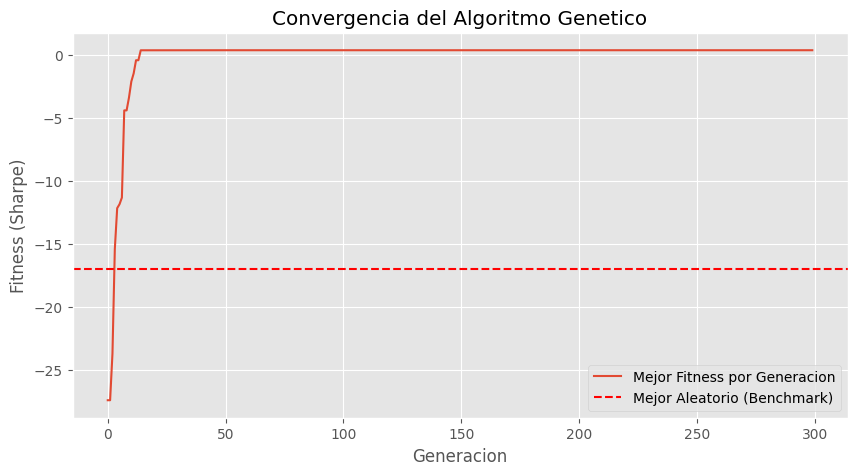

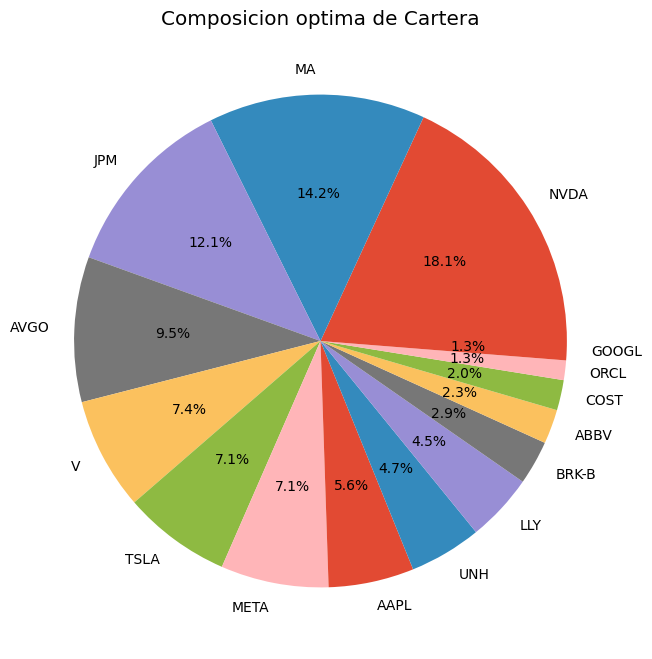

In [14]:
best_ga, historial_ga = algoritmo_genetico(
    tickers=TICKERS,
    rendimientos_esp=r_esp,
    matriz_cov=matriz_cov,
    rf=rf_val,
    rendimientos_diarios=r_diarios,
    perfil=PERFIL_ACTUAL,
    generaciones=300
)

print(f"\nMejor Sharpe GA: {best_ga['sharpe']:.4f}")
print(f"Mejora sobre Aleatorio: {((best_ga['sharpe'] - best_random['sharpe']) / best_random['sharpe']) * 100:.2f}%")

plt.figure(figsize=(10, 5))
plt.plot(historial_ga, label='Mejor Fitness por Generacion')
plt.axhline(best_random['fitness'], color='r', linestyle='--', label='Mejor Aleatorio (Benchmark)')
plt.title("Convergencia del Algoritmo Genetico")
plt.xlabel("Generacion")
plt.ylabel("Fitness (Sharpe)")
plt.legend()
plt.show()

w_series = pd.Series(best_ga['pesos'], index=TICKERS)
w_series = w_series[w_series > 0.01].sort_values(ascending=False)

w_series.plot.pie(autopct='%1.1f%%', figsize=(8, 8), title="Composicion optima de Cartera")
plt.ylabel('')
plt.show()

# 7. Conclusiones y Discusion

Tras la implementacion y comparacion de metodos estocasticos (Muestreo Aleatorio) frente a metodos metaheuristicos (Algoritmos Geneticos y Temple Simulado) para la optimizacion de un portafolio de inversion bajo el modelo de Markowitz, se desprenden los siguientes hallazgos:

### 1. Superioridad sobre el Azar (Validacion de la Heuristica)
Los resultados demuestran contundentemente que la busqueda guiada (GA y SA) supera al muestreo aleatorio puro (Monte Carlo).
* Mientras que el azar se distribuye en una curva normal alrededor de un promedio mediocre, las metaheuristicas lograron sistematicamente encontrar combinaciones de pesos en la "cola derecha" de la distribucion (altos Ratios de Sharpe).
* Esto valida que los mecanismos de **seleccion, cruce y mutacion** (en GA) y el **enfriamiento estadistico** (en SA) son efectivos para navegar el espacio de soluciones multidimensional.

### 2. La Limitante Teorica: Metaheuristicas vs. Metodos Exactos
Desde una perspectiva critica, es importante notar que el problema de optimizacion de portafolios estandar (Media-Varianza) es un problema **Convexo** (Cuadratico).



* **El Hallazgo:** En problemas convexos como este, los metodos basados en calculo (derivadas, multiplicadores de Lagrange o programacion cuadratica como `SLSQP`) garantizan encontrar el **Óptimo Global** exacto en tiempos computacionales insignificantes.
* **La Critica:** Utilizar metaheuristicas (GA/SA) para este problema "de libro de texto" es computacionalmente ineficiente comparado con un solver matematico. Las metaheuristicas aproximan la solucion, pero rara vez alcanzan la precision decimal de un metodo de gradiente, ya que dependen de componentes estocasticos.

### 3. ¿Cuando se justifica el uso de Metaheuristicas?
Si bien para el modelo basico de Markowitz son suboptimas, los algoritmos implementados (GA y SA) se vuelven indispensables en escenarios financieros mas realistas donde las derivadas no pueden aplicarse (funciones **No Convexas** o discontinuas):
* **Restricciones de Cardinalidad:** "Seleccionar exactamente k activos de n posibles" (Problema combinatorio NP-Hard).
* **Lotes Minimos (Buy-in thresholds):** "Si compro Apple, debo invertir al menos $5,000".
* **Costos de Transaccion No Lineales:** Costos que varian escalonadamente.
En estos casos, el espacio de busqueda se vuelve irregular, y los solvers matematicos tradicionales fallan, mientras que los Algoritmos Geneticos prosperan.

### 4. Oportunidades de Mejora Algoritmica
El desempeño observado en este proyecto podria mejorarse abordando las siguientes areas:
* **Ajuste de Hiperparametros:** En lugar de valores fijos (mutacion 0.15, poblacion 100), se podria implementar una Grid Search para encontrar la configuracion optima del algoritmo.
* **Hibridacion (Algoritmos Memeticos):** Combinar la exploracion global del Genetico con una busqueda local intensiva como Hill Climbing al final de cada generacion para refinar los pesos.
* **Frontera de Pareto:** En lugar de maximizar una sola metrica (Sharpe), utilizar algoritmos multiobjetivo (como NSGA-II) para generar toda la Frontera Eficiente en una sola ejecucion.

**Conclusion General:**
El proyecto demuestra que la metaheuristicas es una herramienta poderosa y flexible capaz de encontrar soluciones de alta calidad sin conocer la estructura matematica interna del problema, aunque para problemas convexos puros, la matematica formal sigue siendo el estandar en eficiencia.